In [53]:
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
titanic=sns.load_dataset('titanic')

In [55]:
titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [56]:
titanic[["fare","age","sibsp","parch"]]=titanic[["fare","age","sibsp","parch"]].fillna(titanic[["fare","age","sibsp","parch"]].mean(),inplace=True)

/tmp/ipykernel_5919/2351402117.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic[["fare","age","sibsp","parch"]]=titanic[["fare","age","sibsp","parch"]].fillna(titanic[["fare","age","sibsp","parch"]].mean(),inplace=True)


In [57]:
# categorical columns
# 	survived	pclass	sex		embarked	class	who	adult_male	deck	embark_town	alive	alone


In [58]:
titanic[["survived","pclass","sex","embarked","class","who","adult_male","deck","embark_town","alive","alone"]]=titanic[["survived","pclass","sex","embarked","class","who","adult_male","deck","embark_town","alive","alone"]].fillna(titanic[["survived","pclass","sex","embarked","class","who","adult_male","deck","embark_town","alive","alone"]].mode().iloc[0])

In [59]:
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

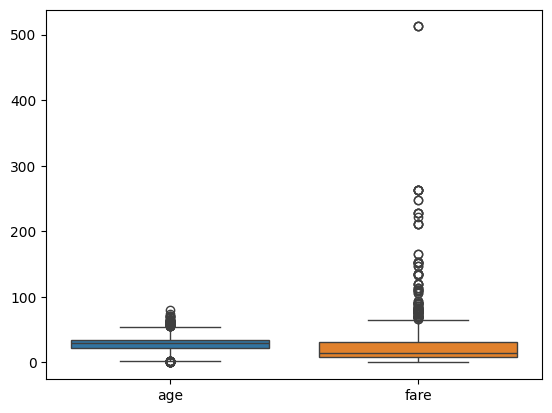

In [60]:
sns.boxplot(data=titanic[["age","fare"]])
plt.show()

In [61]:
Q1=titanic["age"].quantile(0.25)
Q3=titanic["age"].quantile(0.75)
IQR=Q3-Q1
upper_limit=Q3+1.5*IQR
lower_limit=Q1-1.5*IQR
outliers=titanic["age"][(titanic["age"]<lower_limit) |(titanic["age"]>upper_limit)]
print(outliers)

7       2.00
11     58.00
15     55.00
16      2.00
33     66.00
       ...  
827     1.00
829    62.00
831     0.83
851    74.00
879    56.00
Name: age, Length: 66, dtype: float64


In [70]:
Q1=titanic["age"].quantile(0.25)
Q3=titanic["age"].quantile(0.75)
IQR=Q3-Q1
upper_limit=Q3+1.5*IQR
lower_limit=Q1-1.5*IQR

outliers=titanic["age"][(titanic["age"]<lower_limit) |(titanic["age"]>upper_limit)]

titanic["age"]=titanic["age"].clip(lower_limit,upper_limit)
print(outliers)

Series([], Name: age, dtype: float64)


In [71]:
Q1=titanic["fare"].quantile(0.25)
Q3=titanic["fare"].quantile(0.75)
IQR=Q3-Q1
upper_limit=Q3+1.5*IQR
lower_limit=Q1-1.5*IQR

outliers=titanic["fare"][(titanic["fare"]<lower_limit) |(titanic["fare"]>upper_limit)]

titanic["fare"]=titanic["fare"].clip(lower_limit,upper_limit)
print(outliers)

Series([], Name: fare, dtype: float64)


In [64]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [65]:
titanic.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,2,Third,man,True,C,Southampton,no,False
1,1,1,female,38.0,1,0,65.6344,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,2,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,2,Third,man,True,C,Southampton,no,True


In [66]:
titanic = pd.get_dummies(titanic, columns=["sex"])
titanic.head(5)

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_female,sex_male
0,0,3,22.0,1,0,7.2500,2,Third,man,True,C,Southampton,no,False,False,True
1,1,1,38.0,1,0,65.6344,0,First,woman,False,C,Cherbourg,yes,False,True,False
2,1,3,26.0,0,0,7.9250,2,Third,woman,False,C,Southampton,yes,True,True,False
3,1,1,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False,True,False
4,0,3,35.0,0,0,8.0500,2,Third,man,True,C,Southampton,no,True,False,True


In [67]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
SS=StandardScaler()
titanic["age"]=SS.fit_transform(titanic[["age"]])

In [68]:
titanic.head(5)

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_female,sex_male
0,0,3,-0.611917,1,0,7.2500,2,Third,man,True,C,Southampton,no,False,False,True
1,1,1,0.715304,1,0,65.6344,0,First,woman,False,C,Cherbourg,yes,False,True,False
2,1,3,-0.280111,0,0,7.9250,2,Third,woman,False,C,Southampton,yes,True,True,False
3,1,1,0.466450,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False,True,False
4,0,3,0.466450,0,0,8.0500,2,Third,man,True,C,Southampton,no,True,False,True


In [69]:
MS=MinMaxScaler()
titanic["fare"]=MS.fit_transform(titanic[["fare"]])
titanic

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_female,sex_male
0,0,3,-0.611917,1,0,0.110460,2,Third,man,True,C,Southampton,no,False,False,True
1,1,1,0.715304,1,0,1.000000,0,First,woman,False,C,Cherbourg,yes,False,True,False
2,1,3,-0.280111,0,0,0.120745,2,Third,woman,False,C,Southampton,yes,True,True,False
3,1,1,0.466450,1,0,0.809027,2,First,woman,False,C,Southampton,yes,False,True,False
4,0,3,0.466450,0,0,0.122649,2,Third,man,True,C,Southampton,no,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,-0.197160,0,0,0.198067,2,Second,man,True,C,Southampton,no,True,False,True
887,1,1,-0.860771,0,0,0.457077,2,First,woman,False,B,Southampton,yes,True,True,False
888,0,3,0.026735,1,2,0.357282,2,Third,woman,False,C,Southampton,no,False,True,False
889,1,1,-0.280111,0,0,0.457077,0,First,man,True,C,Cherbourg,yes,True,False,True
